<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/1.quantum-ml-overview/qml-pipeline/3_3_pca_projection_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/1.quantum-ml-overview/qml-pipeline/3_3_pca_projection_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.3 PCA Projection Visualization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/1.quantum-ml-overview/qml-pipeline/3_3_pca_projection_visualization.ipynb)

이 노트북은 `3-3.py`의 20차원 데이터 생성, PCA 차원 축소, 2차원 시각화 실습을 Colab용으로 정리한 버전입니다.

## 학습 목표

- 고차원 synthetic classification dataset을 생성합니다.
- PCA로 20차원 feature를 2차원으로 축소합니다.
- 축소된 공간에서 class 분포를 시각화하고 해석합니다.

## 진행 순서

1. 20차원 이진 분류 데이터를 생성합니다.
2. PCA를 적용해 2차원 representation을 만듭니다.
3. 설명 분산 비율을 확인합니다.
4. PCA 평면에서 class 분포를 시각화합니다.


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

## 1. 20차원 데이터 생성

`n_informative=10`, `n_redundant=5`로 설정해 실제 정보가 있는 feature와 중복 feature가 함께 있는 데이터를 만듭니다.


In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    random_state=42,
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 20)
y shape: (1000,)


## 2. PCA로 2차원 축소

PCA는 데이터의 분산을 가장 많이 설명하는 방향을 찾아 고차원 데이터를 낮은 차원으로 투영합니다.


In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (1000, 2)
Explained variance ratio: [0.25138183 0.19102774]
Total explained variance: 0.4424095693187854


## 3. PCA 평면 시각화

PCA 결과는 원본 20차원 데이터를 완벽히 보존하지 않습니다. 그래도 class가 어느 정도 분리되는지 빠르게 관찰하는 데 유용합니다.


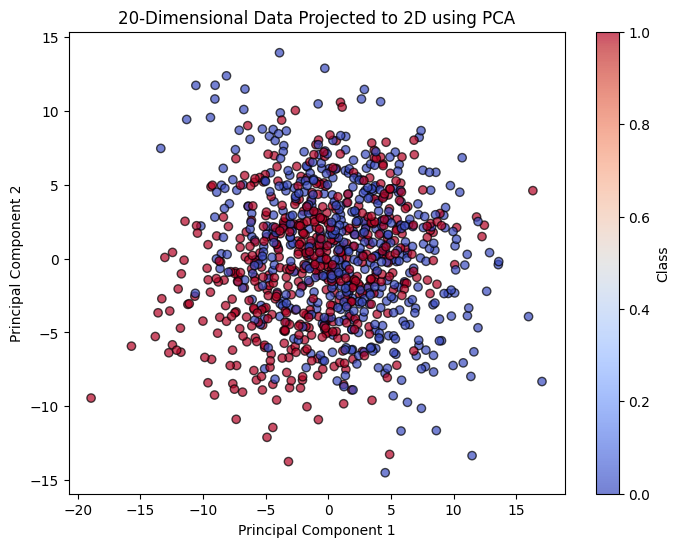

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7,
    edgecolors="k",
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("20-Dimensional Data Projected to 2D using PCA")
plt.colorbar(label="Class")
plt.show()

## 실습 과제

`n_informative` 값을 2, 5, 15 등으로 바꿔가며 PCA 시각화와 설명 분산 비율이 어떻게 달라지는지 확인해 보세요.


Total explained variance: 0.6174246442760658


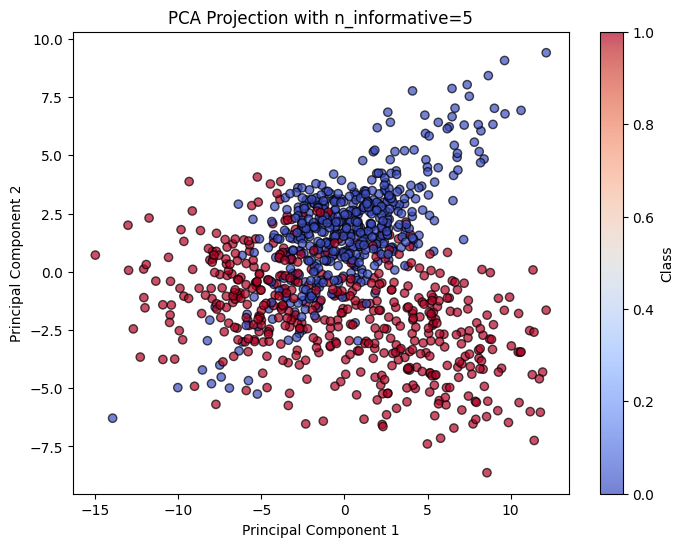

In [5]:
X_experiment, y_experiment = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    random_state=42,
)

pca_experiment = PCA(n_components=2)
X_experiment_pca = pca_experiment.fit_transform(X_experiment)

print("Total explained variance:", pca_experiment.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(
    X_experiment_pca[:, 0],
    X_experiment_pca[:, 1],
    c=y_experiment,
    cmap="coolwarm",
    alpha=0.7,
    edgecolors="k",
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection with n_informative=5")
plt.colorbar(label="Class")
plt.show()

## 정리

- 고차원 데이터는 그대로 시각화하기 어렵기 때문에 PCA 같은 차원 축소가 필요합니다.
- PCA의 2개 성분이 설명하는 분산 비율이 낮으면 2차원 그림만으로 전체 구조를 판단하기 어렵습니다.
- 차원 축소 시각화는 모델 학습 전 데이터 구조를 빠르게 점검하는 용도로 사용합니다.
